### Temporal dynamics have been a game-changer for movie recommender that led to winning Netflix Price.
What is temporal dynamics?
In real world, we have observed that our tastes and preferences changes over time due to new emerging trends, becoming a parent, moving to a new place, etc. That same logic applies to movies, where in 2023 summer, Oppenheimer and Barbie were trending. But today in 2026, that trend has cool down. 

So, to account for these changes over time, we use temporal dynamics, which refers to the study of how system, process, or phenomena changes, evolve or unfold over time. Here is the formula from the Koren's research paper:

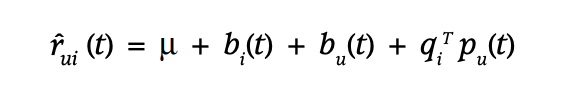


t = normalized time of the rating to prevent overfitting
alpha u = user-specific drift

We keep latent factors Pu and Qi mostly static but make the bias terms time-dependent. Therefore, we treat user bu as a function of time.

For this notebook, we are going to user-specific drift and later experiment with item-specific drift.

### Here is the link to the research paper: [Netflix Paper](https://datajobs.com/data-science-repo/Recommender-Systems-%5BNetflix%5D.pdf)
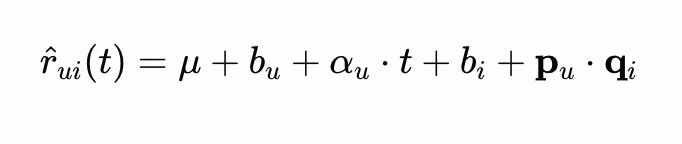

In [71]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import optuna
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error, r2_score

from scipy.sparse.linalg import svds
from scipy.sparse import coo_matrix

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/movies.csv
/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/ratings.csv
/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/README.txt
/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/tags.csv
/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/links.csv


<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #qf1323, #100043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #003ac8;
    text-shadow: 0 0 12px rgba(0,115,400,0.5);
  ">
    <span style="color:#7aa6ec5;">Load the DataFrame</span> 
  </h1>
</div>

In [72]:
df = pd.read_csv('/kaggle/input/datasets/shubhammehta21/movie-lens-small-latest-dataset/ratings.csv')

In [73]:
# Show first five rows
df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [74]:
df = df.rename(columns = {'userId': 'user_id', 'movieId': 'movie_id'})

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df.describe()

##### Deducting 1 from user_id and movie_id since the numPy arrays starts from 0 and as you see from the minimum values for both the columns are 1.

In [75]:
df['user_id'] = df['user_id'] - 1
df['movie_id'] = df['movie_id'] - 1

In [ ]:
df.describe()

<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #qf1323, #100043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #003ac8;
    text-shadow: 0 0 12px rgba(0,115,400,0.5);
  ">
    <span style="color:#7aa6ec5;">Splitting the Data into Train and Test</span> 
  </h1>
</div>

#### Added global number since the model was issuing <code>IndexError</code>: index 609 is out of bounds for axis 0 with size 609. So global number makes sure that the index is not out of bounds.

In [76]:
# Compute the global sizes before splitting
n_users_global = df['user_id'].max() + 1
n_movies_global = df['movie_id'].max() + 1
print(f"Global users: {n_users_global} | Global movies: {n_movies_global}")

Global users: 610 | Global movies: 193609


# Time Split

In [101]:
df = df.sort_values('timestamp') # Sorting the data

sort_index = int(len(df) * 0.64)

train_df = df[:sort_index]
test_df = df[sort_index:]

# Our model expect arrays 
train_users = train_df['user_id'].values
train_movies = train_df['movie_id'].values
train_ratings = train_df['rating'].values
train_timestamps = train_df['timestamp'].values

test_users = test_df['user_id'].values
test_movies = test_df['movie_id'].values
test_ratings = test_df['rating'].values
test_timestamps = test_df['timestamp'].values

print(f"Time-based split → Train: {len(train_df)} ratings (older) | Test: {len(test_df)} ratings (newer)")

Time-based split → Train: 64535 ratings (older) | Test: 36301 ratings (newer)


<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #qf1323, #100043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #003ac8;
    text-shadow: 0 0 12px rgba(0,115,400,0.5);
  ">
    <span style="color:#7aa6ec5;">MatrixFactorizationSGD with user and item biases, and temporal dynamics
    </span> 
  </h1>
</div>

In [102]:
class MatrixFactorizationSGD:
    """
    Matrix Factorization with Biases + Temporal Dynamics
    (User drift over time — the Netflix Prize upgrade!)
    """
    def __init__(self, n_factors=20, learning_rate=0.01, epochs=50, 
                 batch_size=1, reg=None, reg_param=0.01,
                 n_users=None, n_items=None):
        self.n_factors = n_factors
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.reg = reg
        self.reg_param = reg_param
        self.n_users = n_users
        self.n_items = n_items
        
        self.P = None
        self.Q = None
        self.global_bias = 0.0
        self.user_bias = None
        self.item_bias = None
        
        self.user_drift = None  
        self.item_drift = None

    def fit(self, user_ids, item_ids, ratings, timestamps):
        """timestamps must be provided (same length as ratings)"""
        user_ids = np.asarray(user_ids, dtype=int)
        item_ids = np.asarray(item_ids, dtype=int)
        ratings = np.asarray(ratings, dtype=float)
        timestamps = np.asarray(timestamps, dtype=float)
        
        n_users = self.n_users if self.n_users is not None else (user_ids.max() + 1)
        n_items = self.n_items if self.n_items is not None else (item_ids.max() + 1)
        
        self.P = np.random.normal(0, 0.01, (n_users, self.n_factors))
        self.Q = np.random.normal(0, 0.01, (n_items, self.n_factors))
        self.global_bias = np.mean(ratings)
        
        self.user_bias = np.zeros(n_users)
        self.item_bias = np.zeros(n_items)

        self.user_drift = np.zeros(n_users)
        self.item_drift = np.zeros(n_items)
        
        # Normalize timestamp from 0 to 1 to prevent overfitting
        t_min, t_max = timestamps.min(), timestamps.max()
        t_norm = (timestamps - t_min) / (t_max - t_min) if t_max > t_min else np.zeros_like(timestamps)
        
        for epoch in range(self.epochs):
            indices = np.random.permutation(len(ratings))
            for i in range(0, len(ratings), self.batch_size):
                batch_idx = indices[i:i + self.batch_size]
                u_batch = user_ids[batch_idx]
                i_batch = item_ids[batch_idx]
                r_batch = ratings[batch_idx]
                t_batch = t_norm[batch_idx]
                
                pred = (np.sum(self.P[u_batch] * self.Q[i_batch], axis=1) 
                        + self.global_bias 
                        + self.user_bias[u_batch] 
                        + self.item_bias[i_batch]
                        + self.user_drift[u_batch] * t_batch  # multipy user bias with normalized timestamp
                        + self.item_drift[i_batch] * t_batch)
                
                error = r_batch - pred
                
                # Gradients (latent + biases unchanged)
                grad_P = -2 * (error[:, np.newaxis] * self.Q[i_batch])
                grad_Q = -2 * (error[:, np.newaxis] * self.P[u_batch])
                grad_user_bias = -2 * error
                grad_item_bias = -2 * error
                
                # TEMPORAL DYNAMICS: Gradient for user and item drift
                grad_user_drift = -2 * error * t_batch
                grad_item_drift = -2 * error * t_batch
                
                # Regularization (L2 on everything)
                if self.reg == 'l2':
                    grad_P += 2 * self.reg_param * self.P[u_batch]
                    grad_Q += 2 * self.reg_param * self.Q[i_batch]
                    grad_user_bias += 2 * self.reg_param * self.user_bias[u_batch]
                    grad_item_bias += 2 * self.reg_param * self.item_bias[i_batch]
                    grad_user_drift += 2 * self.reg_param * self.user_drift[u_batch]
                    grad_item_drift += 2 * self.reg_param * self.item_drift[i_batch]

                elif self.reg == 'l1':
                    grad_P += self.reg_param * np.sign(self.P[u_batch])
                    grad_Q += self.reg_param * np.sign(self.Q[i_batch])
                    grad_user_bias += self.reg_param * np.sign(self.user_bias[u_batch])
                    grad_item_bias += self.reg_param * np.sign(self.item_bias[i_batch])
                    grad_user_drift += self.reg_param * np.sign(self.user_drift[u_batch])
                    grad_item_drift += self.reg_param * np.sign(self.item_drift[i_batch])
                
                self.P[u_batch] -= self.learning_rate * grad_P
                self.Q[i_batch] -= self.learning_rate * grad_Q
                self.user_bias[u_batch] -= self.learning_rate * grad_user_bias
                self.item_bias[i_batch] -= self.learning_rate * grad_item_bias
                self.user_drift[u_batch] -= self.learning_rate * grad_user_drift   
                self.item_drift[i_batch] -= self.learning_rate * grad_item_drift   
            
        
        return self
    
    def predict(self, user_ids, item_ids, timestamps):
        user_ids = np.asarray(user_ids, dtype=int)
        item_ids = np.asarray(item_ids, dtype=int)
        timestamps = np.asarray(timestamps, dtype=float)
        
        # Same normalization as in training
        t_min, t_max = timestamps.min(), timestamps.max()  # or use global min/max from training
        t_norm = (timestamps - t_min) / (t_max - t_min) if t_max > t_min else np.zeros_like(timestamps)
        
        return (np.sum(self.P[user_ids] * self.Q[item_ids], axis=1) 
                + self.global_bias 
                + self.user_bias[user_ids] 
                + self.item_bias[item_ids]
                + self.user_drift[user_ids] * t_norm
                + self.item_drift[item_ids] * t_norm)
        
    

In [104]:
model = MatrixFactorizationSGD(n_factors=10, learning_rate=0.01, epochs=10, 
                               reg=None, reg_param=0.02, batch_size=32, n_users=n_users_global, n_items=n_movies_global)

model.fit(train_users, train_movies, train_ratings, train_timestamps)


In [105]:
test_pred = model.predict(test_users, test_movies, test_timestamps)
rmse = np.sqrt(mean_squared_error(test_ratings, test_pred))
print(rmse)

1.0112213198771256


<div style="
  border-radius: 20px;
  padding: 25px;
  background: radial-gradient(circle at top, #qf1323, #100043);
  border: 2px solid #00ffc8;
  text-align: center;
  box-shadow: 0 0 25px rgba(0, 255, 250, 0.25);
">
  <h1 style="
    font-size: 28px;
    font-family: 'Trebuchet MS', sans-serif;
    letter-spacing: 2px;
    color: #003ac8;
    text-shadow: 0 0 12px rgba(0,115,400,0.5);
  ">
    <span style="color:#7aa6ec5;">Optuna Study</span> 
  </h1>
</div>

### Conducting optuna study for find the optima hyperparameter configurations for our model:
- setting parameters
- use MatrixFactorizationSGD as the predictive model


In [106]:
def objective(trial):
            
    params = {
        'n_factors': trial.suggest_int('n_factors', 5, 150, step=5),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 0.1, log=True),
        'epochs': trial.suggest_int('epochs', 10, 100),
        'batch_size': trial.suggest_int('batch_size', 16, 320, step=4),  
        'reg': trial.suggest_categorical('reg', ['l2']),
        'reg_param': trial.suggest_float('reg_param', 1e-4, 1.0, log=True),
        'n_users':n_users_global, 
        'n_items':n_movies_global,
    }
    
    model = MatrixFactorizationSGD(**params).fit(train_users, train_movies, train_ratings, train_timestamps)

    pred = model.predict(test_users, test_movies, test_timestamps)

    # adding large penalty instead of crash
    if np.any(np.isnan(pred)):
        return 10.0
        
    rmse = np.sqrt(mean_squared_error(test_ratings, pred))
    return rmse

study = optuna.create_study(direction='minimize', study_name='MFSGD-Optimization', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

[I 2026-03-17 07:32:38,797] A new study created in memory with name: MFSGD-Optimization


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-17 07:32:47,215] Trial 0 finished with value: 1.0178399831650435 and parameters: {'n_factors': 60, 'learning_rate': 0.07114476009343425, 'epochs': 76, 'batch_size': 200, 'reg': 'l2', 'reg_param': 0.00042079886696066364}. Best is trial 0 with value: 1.0178399831650435.
[I 2026-03-17 07:32:53,838] Trial 1 finished with value: 1.0035350519791826 and parameters: {'n_factors': 25, 'learning_rate': 0.00014936568554617635, 'epochs': 88, 'batch_size': 200, 'reg': 'l2', 'reg_param': 0.06796578090758151}. Best is trial 1 with value: 1.0035350519791826.
[I 2026-03-17 07:33:02,174] Trial 2 finished with value: 1.0792159726760975 and parameters: {'n_factors': 5, 'learning_rate': 0.0812324508558869, 'epochs': 85, 'batch_size': 80, 'reg': 'l2', 'reg_param': 0.000533703276260396}. Best is trial 1 with value: 1.0035350519791826.
[I 2026-03-17 07:33:07,189] Trial 3 finished with value: 1.0048214455733637 and parameters: {'n_factors': 30, 'learning_rate': 0.0008179499475211679, 'epochs': 57, '

In [107]:
print("Best Hyperparameters Found:")
print(study.best_params)
print(f"Best RMSE: {study.best_value:.4f}")

Best Hyperparameters Found:
{'n_factors': 40, 'learning_rate': 0.0015613418566555307, 'epochs': 90, 'batch_size': 124, 'reg': 'l2', 'reg_param': 0.3899716109944508}
Best RMSE: 0.9933


In [108]:
best_params = study.best_params.copy()
best_params.update({
    'n_users': n_users_global, 
    'n_items': n_movies_global,
})

best_model = MatrixFactorizationSGD(**best_params).fit(train_users, train_movies, train_ratings, train_timestamps)
final_pred = best_model.predict(test_users, test_movies, test_timestamps)

In [109]:
rmse = np.sqrt(mean_squared_error(test_ratings, final_pred))
mae = mean_absolute_error(test_ratings, final_pred)
r2score = r2_score(test_ratings, final_pred)
explained_var = explained_variance_score(test_ratings, final_pred)

print(f"Final Validation RMSE: {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2score:.4f}")
print(f'Explained Variance Score: {explained_var:.4f}')

Final Validation RMSE: 0.9935
Mean Absolute Error (MAE): 0.7650
R² Score: 0.1075
Explained Variance Score: 0.1091
